# Skripsi Felix — Versi Revisi

Perubahan dibanding notebook asli (`535230119_SkripsiFelix.ipynb`):

1. **Missing value** ditangani sekali di awal untuk keempat variabel (PER, PBV, ROE, DER), tidak lagi terpisah.
2. **Data leakage pada Random Forest diperbaiki** — batas winsorizing P95 untuk ROE dan DER kini dihitung **hanya dari data latih**
   (dan dari fold latih saat cross-validation) lewat `Pipeline`, lalu diterapkan ke data uji.
3. **Evaluasi tambahan**: *balanced accuracy* dan **Repeated Stratified K-Fold CV (5 fold × 10 ulangan)** agar hasil tidak
   bergantung pada satu kali split (kelas *Tinggi* hanya 14 sampel di data uji).
4. Hasil disimpan ke folder `output_revisi/` agar tidak menimpa hasil lama.

Bagian K-Means (preprocessing PER/PBV, K = 3, aturan pelabelan) **tidak diubah**.

In [1]:
#Import Library
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     RepeatedStratifiedKFold, cross_validate)
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
RS = 42

In [2]:
#Dataset
df = pd.read_excel("Dataset September.xlsx")
df = df[["Kode Saham", "Sektor", "PER", "PBV", "ROE %", "DER"]].copy()

df.loc[df["Kode Saham"] == "KETR", "Sektor"] = "Infrastructures"
df.loc[df["Kode Saham"] == "VICI", "Sektor"] = "Consumer Non-Cyclicals"

print(f"Jumlah data   : {len(df)} saham")
print(f"Jumlah sektor : {df['Sektor'].nunique()}")
df.head()

Jumlah data   : 960 saham
Jumlah sektor : 11


,Kode Saham,Sektor,PER,PBV,ROE %,DER
0,AADI,Energy,6.10,1.13,18.58,0.53
1,AALI,Consumer Non-Cyclicals,7.39,0.56,7.59,0.17
2,ABBA,Consumer Cyclicals,-4.78,-0.99,0.00,-2.87
3,ABDA,Financials,17.52,1.32,7.54,0.58
4,ABMM,Industrials,5.11,0.46,8.99,1.30


In [3]:
mv = pd.DataFrame({"jumlah_missing": df.isna().sum(),
                   "persen": (df.isna().mean() * 100).round(3)})
print(mv)
print(f"\nTotal baris yang memuat missing value: {df.isna().any(axis=1).sum()}")
df[df.isna().any(axis=1)]

            jumlah_missing  persen
Kode Saham               0   0.000
Sektor                   0   0.000
PER                      1   0.104
PBV                      1   0.104
ROE %                    1   0.104
DER                      1   0.104

Total baris yang memuat missing value: 1


,Kode Saham,Sektor,PER,PBV,ROE %,DER
328,FREN,Infrastructures,NaN,NaN,NaN,NaN


### Penanganan Missing Value
Baris yang memuat missing value pada salah satu dari PER, PBV, ROE, atau DER dihapus sekaligus di sini,
sehingga data yang dipakai K-Means dan Random Forest identik sejak awal.

In [4]:
#Penanganan Missing Value
n_awal = len(df)
df = df.dropna(subset=["PER", "PBV", "ROE %", "DER"]).reset_index(drop=True)
print(f"Sebelum: {n_awal} | Sesudah: {len(df)} | Dihapus: {n_awal - len(df)}")
print(f"Sisa missing value: {df[['PER', 'PBV', 'ROE %', 'DER']].isna().sum().sum()}")

Sebelum: 960 | Sesudah: 959 | Dihapus: 1
Sisa missing value: 0


In [5]:
n_sebelum = len(df)
print(f"PER <= 0 : {(df['PER'] <= 0).sum()} saham")
print(f"PBV <= 0 : {(df['PBV'] <= 0).sum()} saham")

df = df[(df["PER"] > 0) & (df["PBV"] > 0)].reset_index(drop=True)
print(f"\nSebelum: {n_sebelum} | Sesudah: {len(df)} | Dihapus: {n_sebelum - len(df)}")

PER <= 0 : 325 saham
PBV <= 0 : 52 saham

Sebelum: 959 | Sesudah: 627 | Dihapus: 332


In [6]:
#Winsorizing Upper Only  P95
n = len(df)
L = 1 + (n - 1) * 0.95
print(f"n = {n}  ->  L = 1 + ({n}-1) x 0,95 = {L:.4f}\n")

for c in ["PER", "PBV"]:
    urut = np.sort(df[c].values)
    i = int(L)
    batas = np.percentile(df[c], 95)
    n_cap = (df[c] > batas).sum()
    df[c + "_w"] = np.minimum(df[c], batas)
    print(f"{c}: X{i} = {urut[i-1]:.4f}, X{i+1} = {urut[i]:.4f}  ->  "
          f"P95 = {batas:.4f}  ({n_cap} saham dipotong)")

df[["PER", "PER_w", "PBV", "PBV_w"]].describe().T

n = 627  ->  L = 1 + (627-1) x 0,95 = 595.7000

PER: X595 = 201.8700, X596 = 232.9900  ->  P95 = 223.6540  (32 saham dipotong)
PBV: X595 = 9.9500, X596 = 9.9600  ->  P95 = 9.9570  (32 saham dipotong)


,count,mean,std,min,25%,50%,75%,max
PER,627.0,123.837767,1262.702939,0.31,8.295,14.51,40.125,30826.300
PER_w,627.0,38.892772,55.373035,0.31,8.295,14.51,40.125,223.654
PBV,627.0,3.865263,17.568178,0.04,0.650,1.20,2.260,302.810
PBV_w,627.0,2.169416,2.542534,0.04,0.650,1.20,2.260,9.957


In [7]:
#Standardisasi Relatif Sektor
stat_sektor = df.groupby("Sektor").agg(
    n=("Kode Saham", "count"),
    mu_PER=("PER_w", "mean"), sigma_PER=("PER_w", lambda s: s.std(ddof=1)),
    mu_PBV=("PBV_w", "mean"), sigma_PBV=("PBV_w", lambda s: s.std(ddof=1)))
stat_sektor

,n,mu_PER,sigma_PER,mu_PBV,sigma_PBV
Sektor,,,,,
Basic Materials,78,28.620487,43.084087,1.574410,1.808714
Consumer Cyclicals,82,39.509951,55.464288,2.197744,2.708793
Consumer Non-Cyclicals,96,34.160250,55.498278,2.810302,2.985784
Energy,66,39.612909,55.887190,2.871545,3.166548
Financials,82,35.142585,47.645600,1.440976,1.801953
Healthcare,32,55.649875,74.551417,2.553031,2.182104
Industrials,42,31.637238,44.880256,2.371690,2.830841
Infrastructures,40,37.846200,55.469202,2.382025,2.580538
Properties & Real Estate,52,39.809808,44.656754,1.301346,1.320141


In [8]:
g = df.groupby("Sektor")
for c in ["PER", "PBV"]:
    df[c + "_z"] = g[c + "_w"].transform(lambda s: (s - s.mean()) / s.std(ddof=1))

X_k = df[["PER_z", "PBV_z"]].values

# verifikasi: mean tiap sektor harus 0, std harus 1
cek = df.groupby("Sektor")[["PER_z", "PBV_z"]].agg(["mean", "std"]).round(4)
print("Verifikasi (mean ~0, std ~1):")
cek

Verifikasi (mean ~0, std ~1):


PER_z      PBV_z     
                           mean  std  mean  std
Sektor                                         
Basic Materials            -0.0  1.0   0.0  1.0
Consumer Cyclicals          0.0  1.0  -0.0  1.0
Consumer Non-Cyclicals     -0.0  1.0   0.0  1.0
Energy                      0.0  1.0  -0.0  1.0
Financials                 -0.0  1.0   0.0  1.0
Healthcare                  0.0  1.0  -0.0  1.0
Industrials                 0.0  1.0  -0.0  1.0
Infrastructures            -0.0  1.0   0.0  1.0
Properties & Real Estate    0.0  1.0  -0.0  1.0
Technology                 -0.0  1.0  -0.0  1.0
Transportation & Logistic   0.0  1.0  -0.0  1.0

 K       WCSS  Silhouette      DBI
 2 539.809760    0.682842 0.762997
 3 374.829275    0.673138 0.796910
 4 241.527805    0.657924 0.664548
 5 188.894896    0.536723 0.742813
 6 160.216206    0.540202 0.739080

Silhouette tertinggi : K = 2
DBI terendah         : K = 4


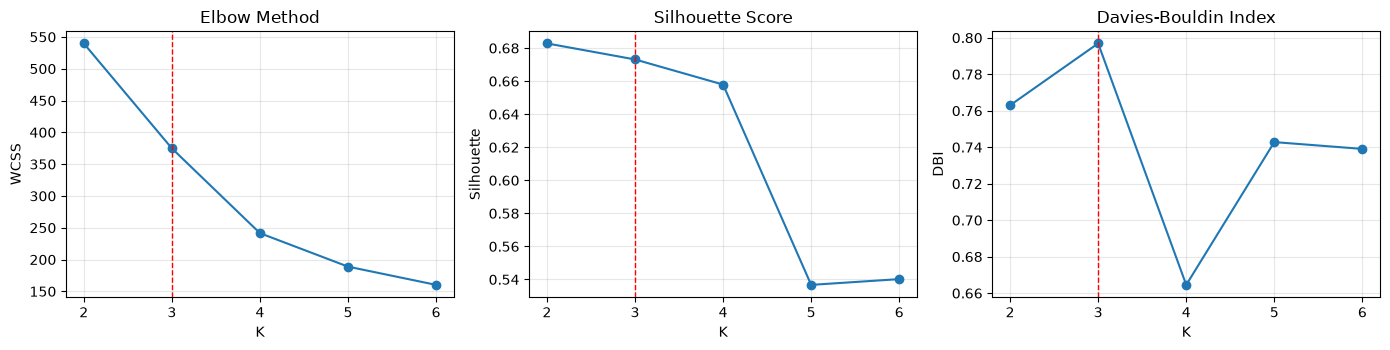

In [9]:
#K-Means Clustering
hasil = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=50, random_state=RS).fit(X_k)
    hasil.append({"K": k, "WCSS": km.inertia_,
                  "Silhouette": silhouette_score(X_k, km.labels_),
                  "DBI": davies_bouldin_score(X_k, km.labels_)})
df_k = pd.DataFrame(hasil)
print(df_k.to_string(index=False))
print(f"\nSilhouette tertinggi : K = {df_k.loc[df_k.Silhouette.idxmax(), 'K']}")
print(f"DBI terendah         : K = {df_k.loc[df_k.DBI.idxmin(), 'K']}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, col, judul in zip(ax, ["WCSS", "Silhouette", "DBI"],
                         ["Elbow Method", "Silhouette Score", "Davies-Bouldin Index"]):
    a.plot(df_k.K, df_k[col], marker="o")
    a.axvline(3, color="red", ls="--", lw=1)
    a.set(title=judul, xlabel="K", ylabel=col, xticks=df_k.K)
    a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [10]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=50, random_state=RS).fit(X_k)
df["cluster"] = kmeans.labels_

print(f"WCSS       : {kmeans.inertia_:.4f}")
print(f"Silhouette : {silhouette_score(X_k, df['cluster']):.4f}")
print(f"DBI        : {davies_bouldin_score(X_k, df['cluster']):.4f}")
print(f"Iterasi    : {kmeans.n_iter_}")

centroid = pd.DataFrame(kmeans.cluster_centers_, columns=["PER_z", "PBV_z"])
centroid["jumlah"] = df["cluster"].value_counts().sort_index()
centroid

WCSS       : 374.8293
Silhouette : 0.6731
DBI        : 0.7969
Iterasi    : 8


,PER_z,PBV_z,jumlah
0,-0.376982,-0.323966,511
1,2.105211,-0.049126,45
2,1.378916,2.362779,71


In [11]:
c = kmeans.cluster_centers_
skor = c.sum(axis=1)
neg = [i for i in range(K) if c[i, 0] < 0 and c[i, 1] < 0]
pos = [i for i in range(K) if c[i, 0] > 0 and c[i, 1] > 0]

label = {}
if neg: label[min(neg, key=lambda i: skor[i])] = "Valuasi Relatif Rendah"
if pos: label[max(pos, key=lambda i: skor[i])] = "Valuasi Relatif Tinggi"
for i in range(K):
    label.setdefault(i, "Valuasi Relatif Sedang")

if len(neg) > 1 or len(pos) > 1:
    print("PERINGATAN: lebih dari satu cluster memenuhi syarat — tie-break dipakai.\n")

for i in range(K):
    print(f"Cluster {i}: PERz = {c[i,0]:+.4f}, PBVz = {c[i,1]:+.4f}  ->  {label[i]}")

df["label"] = df["cluster"].map(label)
print()
print(df.groupby("label").agg(jumlah=("Kode Saham", "count"),
                              PER_median=("PER", "median"),
                              PBV_median=("PBV", "median")))

Cluster 0: PERz = -0.3770, PBVz = -0.3240  ->  Valuasi Relatif Rendah
Cluster 1: PERz = +2.1052, PBVz = -0.0491  ->  Valuasi Relatif Sedang
Cluster 2: PERz = +1.3789, PBVz = +2.3628  ->  Valuasi Relatif Tinggi

                        jumlah  PER_median  PBV_median
label                                                 
Valuasi Relatif Rendah     511       11.80        1.01
Valuasi Relatif Sedang      45      148.41        1.37
Valuasi Relatif Tinggi      71       93.20        9.29


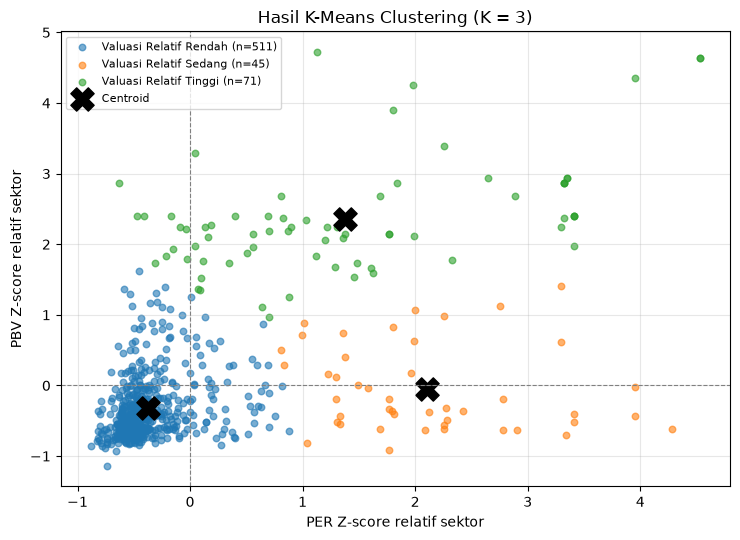

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for i in range(K):
    m = df["cluster"] == i
    ax.scatter(df.loc[m, "PER_z"], df.loc[m, "PBV_z"], s=22, alpha=.6,
               label=f"{label[i]} (n={m.sum()})")
ax.scatter(c[:, 0], c[:, 1], marker="X", s=280, c="black", label="Centroid")
ax.axhline(0, color="gray", ls="--", lw=.8); ax.axvline(0, color="gray", ls="--", lw=.8)
ax.set(xlabel="PER Z-score relatif sektor", ylabel="PBV Z-score relatif sektor",
       title="Hasil K-Means Clustering (K = 3)")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Persiapan Data Random Forest
ROE dan DER **tidak** di-winsorize di sini. Winsorizing dilakukan di dalam `Pipeline` (kelas `WinsorizerAtas`)
sehingga batas P95 dipelajari dari data latih saja, lalu diterapkan ke data uji — mencegah informasi data uji
bocor ke proses pelatihan.

In [13]:
class WinsorizerAtas(BaseEstimator, TransformerMixin):
    """Winsorizing upper-only: nilai di atas persentil q (dari data latih) dipotong."""
    def __init__(self, q=95):
        self.q = q

    def fit(self, X, y=None):
        self.batas_ = np.percentile(np.asarray(X, dtype=float), self.q, axis=0)
        return self

    def transform(self, X):
        return np.minimum(np.asarray(X, dtype=float), self.batas_)


fitur = ["ROE %", "DER"]
print(f"Data untuk Random Forest: {len(df)} saham")
print("\nRentang nilai:")
for c_ in fitur:
    print(f"  {c_:6s}: min = {df[c_].min():.4f}, max = {df[c_].max():.4f}, "
          f"nilai negatif = {(df[c_] < 0).sum()}")

X = df[fitur]
y = df["label"]

Data untuk Random Forest: 627 saham

Rentang nilai:
  ROE % : min = 0.0100, max = 281.5700, nilai negatif = 0
  DER   : min = 0.0000, max = 27.4300, nilai negatif = 0


In [14]:
#Random Forest
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RS)

print(f"Data latih : {len(X_tr)}")
print(f"Data uji   : {len(X_te)}\n")
print(pd.DataFrame({"latih": y_tr.value_counts(), "uji": y_te.value_counts()}))

Data latih : 501
Data uji   : 126

                        latih  uji
label                             
Valuasi Relatif Rendah    408  103
Valuasi Relatif Tinggi     57   14
Valuasi Relatif Sedang     36    9


In [15]:
#Winsorizing P95 — batas dihitung dari data latih saja
w = WinsorizerAtas(95).fit(X_tr)
for c_, b in zip(fitur, w.batas_):
    print(f"  {c_:6s}: P95 (latih) = {b:.4f}  ->  dipotong: latih {(X_tr[c_] > b).sum()}, "
          f"uji {(X_te[c_] > b).sum()}")
print()


def buat_pipeline(**rf_params):
    return Pipeline([("winsor", WinsorizerAtas(95)),
                     ("rf", RandomForestClassifier(class_weight="balanced",
                                                   random_state=RS, **rf_params))])


#Model Awal dan Grid Search
rf_awal = buat_pipeline(n_estimators=100).fit(X_tr, y_tr)
yp = rf_awal.predict(X_te)
print(f"Model awal (n_estimators=100): accuracy = {accuracy_score(y_te, yp):.4f}, "
      f"F1-macro = {f1_score(y_te, yp, average='macro'):.4f}\n")

param_grid = {"rf__n_estimators": [200],
              "rf__max_depth": [None, 5, 10],
              "rf__min_samples_split": [2, 10],
              "rf__min_samples_leaf": [1, 3, 5, 10]}   # 1 x 3 x 2 x 4 = 24 kombinasi

grid = GridSearchCV(buat_pipeline(), param_grid, scoring="f1_macro",
                    cv=StratifiedKFold(5, shuffle=True, random_state=RS), n_jobs=-1)
grid.fit(X_tr, y_tr)
rf = grid.best_estimator_
param_terbaik = {k.replace("rf__", ""): v for k, v in grid.best_params_.items()}
print(f"Parameter terbaik : {param_terbaik}")
print(f"F1-macro CV (latih): {grid.best_score_:.4f}")

  ROE % : P95 (latih) = 30.8600  ->  dipotong: latih 25, uji 5
  DER   : P95 (latih) = 5.1000  ->  dipotong: latih 25, uji 7

Model awal (n_estimators=100): accuracy = 0.6825, F1-macro = 0.4419

Parameter terbaik : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
F1-macro CV (latih): 0.5491


                        precision    recall  f1-score   support

Valuasi Relatif Rendah     0.8681    0.7670    0.8144       103
Valuasi Relatif Sedang     0.4286    0.6667    0.5217         9
Valuasi Relatif Tinggi     0.1905    0.2857    0.2286        14

              accuracy                         0.7063       126
             macro avg     0.4957    0.5731    0.5216       126
          weighted avg     0.7614    0.7063    0.7284       126



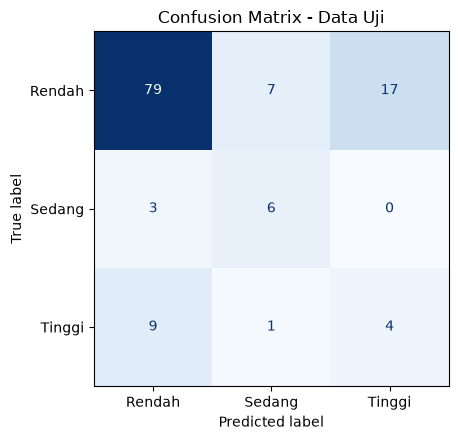

                       Accuracy  Balanced accuracy  F1-macro
Tebak kelas mayoritas    0.8175             0.3333    0.2999
Random Forest            0.7063             0.5731    0.5216


In [16]:
#Evaluasi Confusion Matrix, Accuracy, Precision, Recall, F1-Score
y_pred = rf.predict(X_te)
print(classification_report(y_te, y_pred, digits=4))

kelas = sorted(y.unique())
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred, labels=kelas),
                       display_labels=[k.replace("Valuasi Relatif ", "") for k in kelas]
                       ).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Data Uji")
plt.tight_layout(); plt.show()

# pembanding: menebak kelas mayoritas
y_base = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr).predict(X_te)
print(pd.DataFrame({
    "Accuracy": [accuracy_score(y_te, y_base), accuracy_score(y_te, y_pred)],
    "Balanced accuracy": [balanced_accuracy_score(y_te, y_base),
                          balanced_accuracy_score(y_te, y_pred)],
    "F1-macro": [f1_score(y_te, y_base, average="macro", zero_division=0),
                 f1_score(y_te, y_pred, average="macro")]},
    index=["Tebak kelas mayoritas", "Random Forest"]).round(4))

### Evaluasi Stabilitas — Repeated Stratified K-Fold
Data uji hanya 126 saham (kelas *Sedang* 9, *Tinggi* 14), sehingga skor satu kali split sangat dipengaruhi
keberuntungan pembagian data. Di sini model dengan parameter terbaik dievaluasi ulang pada **seluruh data**
memakai 5-fold × 10 ulangan (50 kali latih–uji). Winsorizing tetap dihitung ulang di setiap fold latih.

Rata-rata ± standar deviasi dari 50 fold:
                              Accuracy Balanced accuracy         F1-macro
Tebak kelas mayoritas  0.8150 ± 0.0028   0.3333 ± 0.0000  0.2994 ± 0.0006
Random Forest          0.7067 ± 0.0307   0.6226 ± 0.0635  0.5348 ± 0.0477


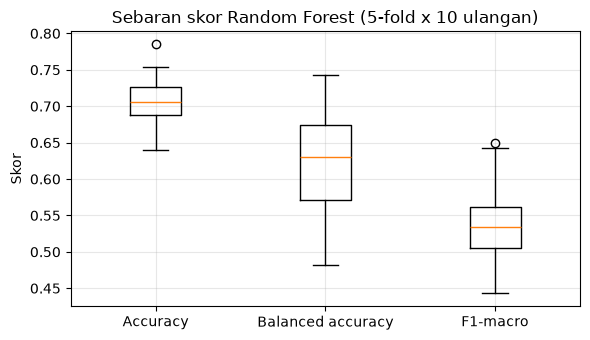

In [17]:
cv_ulang = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RS)
metrik = {"Accuracy": "accuracy", "Balanced accuracy": "balanced_accuracy", "F1-macro": "f1_macro"}

model_cv = {"Tebak kelas mayoritas": DummyClassifier(strategy="most_frequent"),
            "Random Forest": buat_pipeline(**param_terbaik)}

ringkas = {}
for nama, m in model_cv.items():
    s = cross_validate(m, X, y, cv=cv_ulang, scoring=metrik, n_jobs=-1)
    ringkas[nama] = {k: f"{s['test_' + k].mean():.4f} ± {s['test_' + k].std():.4f}"
                     for k in metrik}
    if nama == "Random Forest":
        skor_rf_cv = s

print("Rata-rata ± standar deviasi dari 50 fold:")
print(pd.DataFrame(ringkas).T)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.boxplot([skor_rf_cv["test_" + k] for k in metrik], tick_labels=list(metrik))
ax.set(title="Sebaran skor Random Forest (5-fold x 10 ulangan)", ylabel="Skor")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [18]:
perm = permutation_importance(rf, X_te, y_te, scoring="f1_macro",
                              n_repeats=30, random_state=RS)
print(pd.DataFrame({"MDI": rf.named_steps["rf"].feature_importances_,
                    "Permutation (data uji)": perm.importances_mean},
                   index=["ROE", "DER"]))
print()
print(df.groupby("label")[["ROE %", "DER"]].agg(["mean", "median"]))

          MDI  Permutation (data uji)
ROE  0.713434                0.189394
DER  0.286566                0.026748

                            ROE %              DER       
                             mean median      mean median
label                                                    
Valuasi Relatif Rendah  11.253327   8.24  1.191977   0.69
Valuasi Relatif Sedang   1.212444   0.87  0.934222   0.52
Valuasi Relatif Tinggi  25.954225  10.02  2.803521   1.28


In [19]:
import joblib, os
os.makedirs("output_revisi", exist_ok=True)

# catatan: untuk memuat model RF, kelas WinsorizerAtas harus didefinisikan dulu
joblib.dump(kmeans, "output_revisi/model_kmeans.joblib")
joblib.dump(rf, "output_revisi/model_random_forest.joblib")
stat_sektor.to_csv("output_revisi/statistik_sektor.csv")
df_k.to_csv("output_revisi/evaluasi_k.csv", index=False)
pd.DataFrame(ringkas).T.to_csv("output_revisi/evaluasi_rf_repeated_cv.csv")
df.to_excel("output_revisi/hasil_clustering.xlsx", index=False)

print("Tersimpan di:", os.path.abspath("output_revisi"))
for f in os.listdir("output_revisi"):
    print(" ", f)

Tersimpan di: d:\FELIX\SEMESTER 7\SKRIPSI\CODE\PYTHON\output_revisi
  evaluasi_k.csv
  evaluasi_rf_repeated_cv.csv
  hasil_clustering.xlsx
  model_kmeans.joblib
  model_random_forest.joblib
  statistik_sektor.csv
